In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.interpolate import interp1d
import pandas as pd
from scipy.signal import find_peaks
import math
from decimal import Decimal, getcontext, Overflow

In [2]:
# Constants

c = 3.0e8  # Speed of light in m/s
h = 6.62607015e-34  # Planck's constant in J·s
# Constants
q = 1.602e-19  # Elementary charge in coulombs
k = 1.381e-23  # Boltzmann constant in J/K
T = 300 # Temperature in Kelvin


In [3]:
def custom_converter(value):
    try:
        return float(value)
    except ValueError:
        return float(value.replace('E', 'e'))
        
def planck_law(wavelength, temperature):
    """ Calculate the black body spectrum using Planck's law.
    
    Args:
        wavelength (np.array): Wavelength in meters.
        temperature (float): Temperature in Kelvin.
    
    Returns:
        np.array: Spectral radiance in W*m-2*nm-1
    """
    # Convert wavelength from nm to meters
    wavelength_m = wavelength * 1e-9
    
    # Planck's law
    numerator = 2* math.pi* h * c**2
    denominator = (wavelength_m**5) * (np.exp((h * c) / (wavelength_m * k * temperature)) - 1)
    spectral_radiance = numerator / denominator
    
    # Convert from W/m^3 to W/nm^3
    spectral_radiance_nm = spectral_radiance * 1e-27
    
    return spectral_radiance_nm
    
def photon_flux(wavelength, power):
    #in the unit of s-1 nm-1
    photon_num = 10**-15*(power*wavelength)/h*c
    return photon_num
    
def Reduced_EL(wavelength, power):
    #in the unit of eV
    E3 = (6.24*10**27*h*c/wavelength)**3
    reduced_EL = power/E3
    return reduced_EL

def Reduced_EQE(Energy,EQE):
    reduced_EQE = EQE/Energy
    return reduced_EQE

def normalize_to_local_max(x, y, energy_value, window=0.1):
    # Find indices within the specified energy window
    indices = np.where((x >= energy_value - window) & (x <= energy_value + window))[0]
    
    # Find the local maximum within this window
    local_max_index = indices[np.argmax(y[indices])]
    local_max_value = y[local_max_index]
    
    # Normalize the spectrum to this local maximum
    y_normalized = y / local_max_value
    
    return y_normalized

# Function to find intersection point within a user-defined region
def find_intersection(el_x, el_y, eqe_x, eqe_y, region):
    # Interpolating EL and EQE data within the specified region
    el_interp = interp1d(el_x, el_y , kind='linear', fill_value="extrapolate")
    eqe_interp = interp1d(eqe_x, eqe_y / max(eqe_y), kind='linear', fill_value="extrapolate")
    
    x_min, x_max = region
    x_common = np.linspace(x_min, x_max, 500)
    y_diff = el_interp(x_common) - eqe_interp(x_common)
    
    # Finding the intersection point (only one)
    index = np.where(np.diff(np.sign(y_diff)))[0][0]
    x_intersection = x_common[index]
    y_intersection = el_interp(x_intersection)
    
    return x_intersection, y_intersection

In [4]:
EL_file_ID_1 = '/Users/mingzhu/Library/Mobile Documents/com~apple~CloudDocs/Desktop/EL data/20240522_DCV3T_BHJ_PHJ_T1/DCV3T_Cluster_T1/BHJ_DV30_1dot5V_20dot48mA.csv'
#EL_file_ID_2 = '/Users/mingzhu/Library/Mobile Documents/com~apple~CloudDocs/Desktop/EL data/20241108_FRET_PHJ/SubNc_HB194_PHJ_EL_28dot9mA.csv'
#EL_file_ID_3 = '/Users/mingzhu/Library/Mobile Documents/com~apple~CloudDocs/Desktop/EL data/20240531_SubNc_mono_DCV3T_BHJ_T1/Mono_SubNc_EL_48dot5mA.csv'
#EL_file_ID_4 = '/Users/jswjzhm/Desktop/EL data/DCV3T_Cluster_T1/PHJ_DV33_1dot5V_25dot68mA.csv'
#EL_file_ID_5 = '/Users/jswjzhm/Desktop/EL data/DCV3T_Cluster_T1/SubNc_mono_DV33_1dot5V_50dot74mA.csv'
#EQE_file_ID_1 = '/Users/jswjzhm/Desktop/EQE data and analysis/EQE_analysis/240628_DCV3T_BHJ_OP1/DV03_p4_best_(360-1100nm)'
EQE_file_ID_1 = '/Users/mingzhu/Library/Mobile Documents/com~apple~CloudDocs/Desktop/EQE data and analysis/EQE_analysis/240517_Cluster_DCV3T_PHJ_BHJ_T1/30_p3_best_(360-1100nm)'
#EQE_file_ID_1 = '/Users/jswjzhm/Desktop/EQE data and analysis/EQE_analysis/240517_Cluster_DCV3T_PHJ_BHJ_T1/30_p3_best_(360-1100nm)'
#EQE_file_ID_2 = '/Users/jswjzhm/Desktop/EQE data and analysis/EQE_analysis/240517_Cluster_DCV3T_PHJ_BHJ_T1/33_p4_best_(360-1100nm)'

In [5]:

EL_data_1 = np.loadtxt(EL_file_ID_1, skiprows=3, delimiter=',')
#EL_data_2 = np.loadtxt(EL_file_ID_2, skiprows=3, delimiter=',')
#EL_data_3 = np.loadtxt(EL_file_ID_3, skiprows=3, delimiter=',')
#EL_data_4 = np.loadtxt(EL_file_ID_4, skiprows=3, delimiter=',')
#EL_data_5 = np.loadtxt(EL_file_ID_5, skiprows=3, delimiter=',')
EQE_data_1 = np.loadtxt(EQE_file_ID_1, skiprows=1, delimiter=',')
#EQE_data_2 = np.loadtxt(EQE_file_ID_2, skiprows=1, delimiter=',')

In [6]:
Labels_EL = ['EL']
#Labels_EL = ['2 V 3 mA EL'] ['HB194|DCV3T','SubNc|HB194','SubNc|DCV3T'] ['4.65 mA/cm$^2$', '48.5 mA/cm$^2$']
Labels_EQE = ['EQE']

In [7]:
# Define the list of data sets (JV_data_1, JV_data_2, etc.)
EL_sets = [EL_data_1]  # Add more data sets as needed

Wavelength = []
EVs = []
Power = []
Norm_power = []
EQE_EL = []
Power_Int = []
Red_EL = []


# Iterate over each data set
for data in EL_sets:
    
    interp_wavelength = np.linspace(data[:, 0].min(),data[:, 0].max(),1000)
    
    Power_interp = interp1d(data[:, 0], data[:, 1], kind='linear', bounds_error=False, fill_value=0.0)
    
    Power_interp = Power_interp(interp_wavelength)

    BB_spectrum = planck_law(interp_wavelength, T)


    # Calculate the exponential term using Decimal
    #exp_term = math.exp(q * Voltage[0] / (k * T)) - 1


    # Calculate the full expression in unite of W/nm^3
    Power_unit_convert = (Power_interp * 10**-6) /(30.87 * 10**14)
    EQE_cal_EL = Power_unit_convert /BB_spectrum


    
    Red_EL.append(Reduced_EL(interp_wavelength,Power_interp))
    EQE_EL.append(EQE_cal_EL)
    Power_Int.append(Power_interp)
    Wavelength.append(interp_wavelength)
    EVs.append((h*c)/(interp_wavelength*10**-9 * q))
    Power.append(data[:, 1]) # extract energy values from the data
    Norm_power.append(data[:,1]/max(data[:,1]))


    

In [8]:
EQE_sets = [EQE_data_1]  # Add more data sets as needed

EQE_Wavelength = []
EQE = []
Norm_EQE_log = []
EQE_EV = []
Red_EQE = []



# Iterate over each data set
for data in EQE_sets:
    Red_EQE.append(Reduced_EQE(data[:, 2],data[:, 3]))
    EQE_Wavelength.append(data[:, 1])
    EQE_EV.append(data[:, 2])
    EQE.append(data[:, 3])
    Norm_EQE_log.append(data[:, 3]/max(data[:, 3]))

    

In [9]:
EL_colour= ['#4c85b9', '#c56856','#3399cc']
EQE_colour= ['#0b5394']

In [10]:
Line_style = ['-', '--','-.']

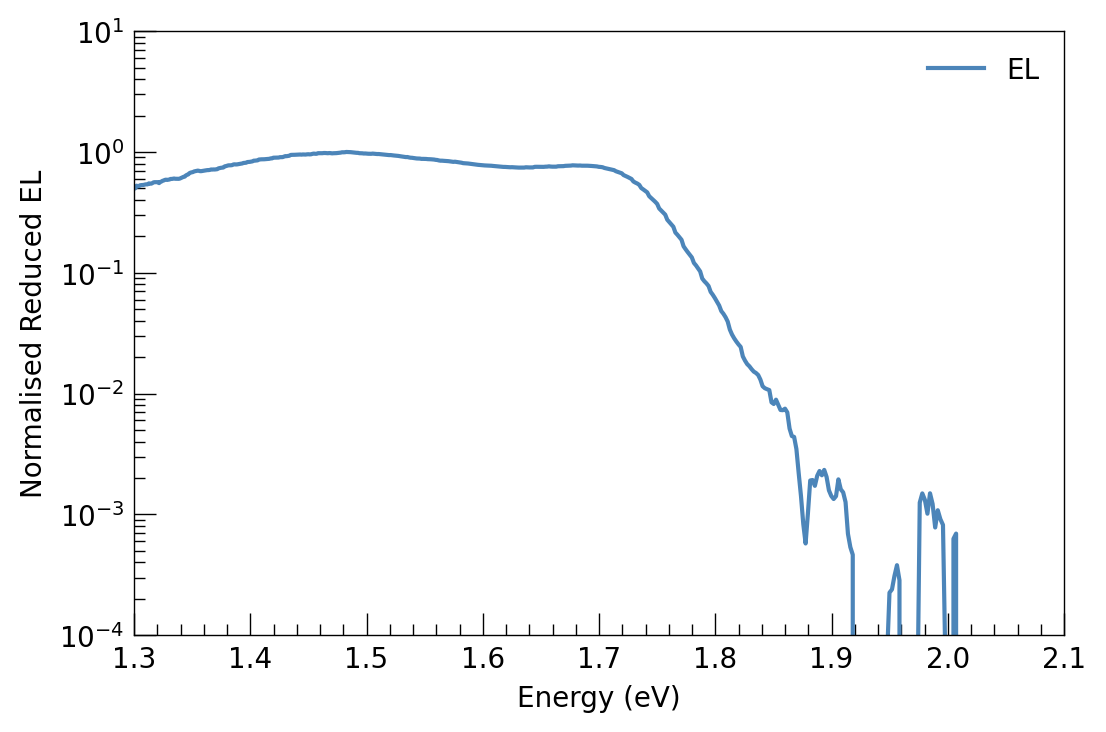

In [11]:
with mpl.rc_context({'axes.linewidth': 0.5}):

    # Create a new figure
    EL_figure = plt.figure(dpi = 200)


    # Iterate over each data set
    for i, data in enumerate(EL_sets):
        # Plot reduced EL in log scale
        plt.semilogy(EVs[i],Red_EL[i]/max(Red_EL[i]),label = Labels_EL[i],linestyle=Line_style[i], color=EL_colour[i])
        
    # # Iterate over each data set
    # for i, data in enumerate(EQE_sets):
    #     # Plot EQE in log scale
    #     plt.semilogy(EQE_EV[i], Red_EQE[i]/max(Red_EQE[i]), label=Labels_EQE[i])

    
        

    # Set the x-axis and y-axis limits
    plt.xlim(1.3, 2.1)  # Adjust the limits as needed
    plt.ylim(10e-5, 10)
    
    # Set x-axis and y-axis labels
    plt.xlabel('Energy (eV)')
    #plt.ylabel('Reduced EL/EQE$_{PV}$ (a.u)')
    plt.ylabel('Normalised Reduced EL')
    
    plt.tick_params(labelsize=10, direction='in', axis='both', which='major', length=8, width=0.5)
    plt.tick_params(labelsize=10, direction='in', axis='both', which='minor', length=4, width=0.5)
    plt.minorticks_on()

    # Add legend
    plt.legend(fontsize=10, frameon=False, loc='best')

    #plt.savefig(f"/Users/mingzhu/Library/Mobile Documents/com~apple~CloudDocs/Desktop/EL data/20240522_DCV3T_BHJ_PHJ_T1/DCV3T_Cluster_T1/SubNc_BHJs_EL_compare.pdf", dpi=300)

    # Show the plot
    plt.show()

    

In [20]:
EL_scaling_factor = 2.1*10e-18

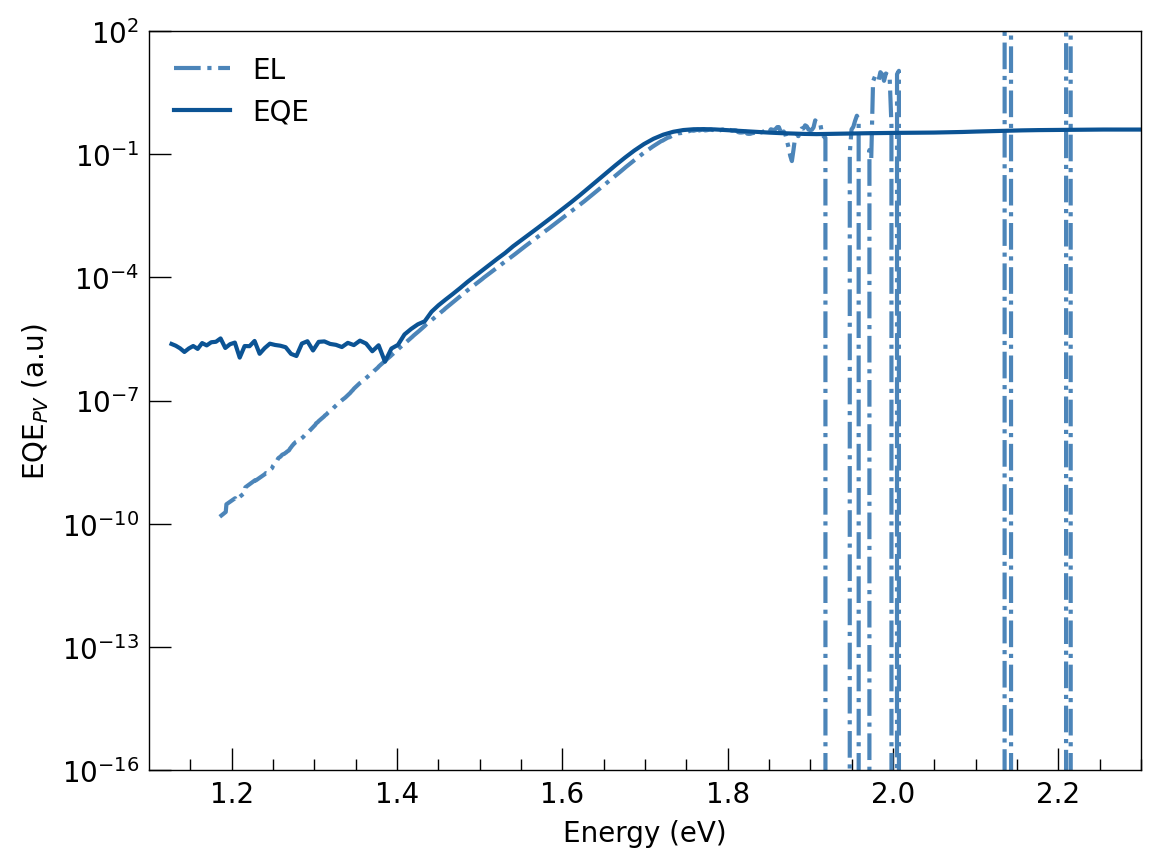

In [22]:
with mpl.rc_context({'axes.linewidth': 0.5}):

    # Create a new figure
    EL_figure = plt.figure(dpi = 200)


    # Iterate over each data set
    for i, data in enumerate(EL_sets):
        # Plot reduced EL in log scale
        plt.semilogy(EVs[i], EL_scaling_factor*EQE_EL[i],label = Labels_EL[i], color=EL_colour[i], linestyle='-.')
        
    # Iterate over each data set
    for i, data in enumerate(EQE_sets):
        # Plot EQE in log scale
        plt.semilogy(EQE_EV[i], EQE[i], label=Labels_EQE[i],color=EQE_colour[i], linestyle='-')

    
        

    # Set the x-axis and y-axis limits
    plt.xlim(1.1, 2.3)  # Adjust the limits as needed
    plt.ylim(10e-17, 100)
    
    # Set x-axis and y-axis labels
    plt.xlabel('Energy (eV)')
    plt.ylabel('EQE$_{PV}$ (a.u)')
    
    plt.tick_params(labelsize=10, direction='in', axis='both', which='major', length=8, width=0.5)
    plt.tick_params(labelsize=10, direction='in', axis='both', which='minor', length=4, width=0.5)
    plt.minorticks_on()

    # Add legend
    plt.legend(fontsize=10, frameon=False, loc='best')

    plt.savefig(f"/Users/mingzhu/Library/Mobile Documents/com~apple~CloudDocs/Desktop/EL data/20240522_DCV3T_BHJ_PHJ_T1/DCV3T_Cluster_T1/SubNc_DCV3T_BHJ_EL_EQE_verify_2E-18.pdf", dpi=300)

    # Show the plot
    plt.show()


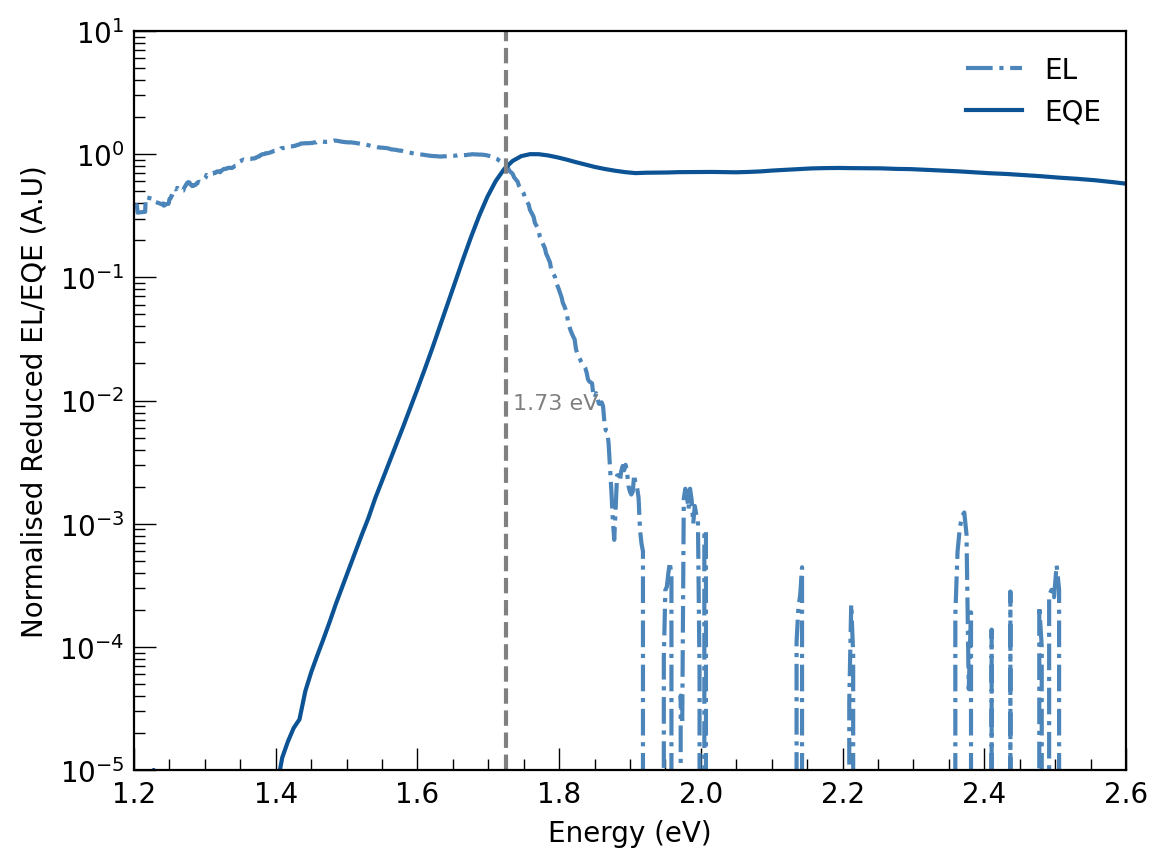

In [28]:
# User-defined region
user_defined_region = (1.6, 2)  # Example values; change as needed

# Create a new figure
plt.figure(dpi=200)

# Assuming only one set of EL and EQE data
el_x, el_y = EVs[0], normalize_to_local_max(EVs[0], Red_EL[0], 1.7, window=0.1)
eqe_x, eqe_y = EQE_EV[0], Red_EQE[0]

# Find the intersection point within the user-defined region
x_int, y_int = find_intersection(el_x, el_y, eqe_x, eqe_y, user_defined_region)

# Plot Reduced EL and EQE
plt.semilogy(el_x, el_y, label=Labels_EL[0], color=EL_colour[i], linestyle='-.')
plt.semilogy(eqe_x, eqe_y/ max(eqe_y), label=Labels_EQE[0],color=EQE_colour[i], linestyle='-')
# 
# Plot vertical dashed grey line at the intersection point
plt.axvline(x=x_int, color='grey', linestyle='--')

# Label the x position of the interception point in the middle of the line
y_mid = 10**((np.log10(1e-2) + np.log10(1.2)) / 2)
plt.text(x_int+0.01, y_mid-0.1, f'{x_int:.2f} eV', fontsize=8, color='grey', ha='left', va='center')

# Set the x-axis and y-axis limits
plt.xlim(1.2, 2.6)
plt.ylim(1e-5, 10)

# Set x-axis and y-axis labels
plt.xlabel('Energy (eV)')
plt.ylabel('Normalised Reduced EL/EQE (A.U)')

plt.tick_params(labelsize=10, direction='in', axis='both', which='major', length=8, width=0.5)
plt.tick_params(labelsize=10, direction='in', axis='both', which='minor', length=4, width=0.5)
plt.minorticks_on()

# Add legend
plt.legend(fontsize=10, frameon=False, loc='best')

plt.savefig(f"/Users/mingzhu/Library/Mobile Documents/com~apple~CloudDocs/Desktop/EL data/20240522_DCV3T_BHJ_PHJ_T1/DCV3T_Cluster_T1/SubNc_DCV3T_BHJ_EL_EQE_Combine.pdf", dpi=300)

# Show the plot
plt.show()

In [29]:
import numpy as np
import pandas as pd
from pathlib import Path

# === FIXED OUTPUT STYLE ===
OUT_SEP = ","                 # tab-separated (like your EQE files)
FLOAT_FMT = "%.8e"             # scientific notation
COLS = ["EQE", "Log_EQE", "Wavelength", "Energy"]

# === Output directory ===
out_dir = Path("/Users/mingzhu/Library/Mobile Documents/com~apple~CloudDocs/Desktop/EL data/20240522_DCV3T_BHJ_PHJ_T1/DCV3T_Cluster_T1")   # <--- change this
out_dir.mkdir(parents=True, exist_ok=True)

for i in range(len(Red_EL)):
    red_el = np.asarray(Red_EL[i], dtype=float)  # this is log10(EL)
    wl_nm      = np.asarray(Wavelength[i], dtype=float)
    ev_eV      = np.asarray(EVs[i], dtype=float)

    # Ensure equal length
    n = min(len(red_el), len(wl_nm), len(ev_eV))
    red_el = red_el[:n]
    wl_nm      = wl_nm[:n]
    ev_eV      = ev_eV[:n]

    # log10(Red_EL); NaN for non-positive
    log10_red_el = np.full_like(red_el, np.nan, dtype=float)
    pos = red_el > 0
    log10_red_el[pos] = np.log10(red_el[pos])  # use np.log for natural log if preferred

    # Build DataFrame
    df = pd.DataFrame({
        "EQE": red_el,
        "Log_EQE": log10_red_el,                       
        "Wavelength": wl_nm,
        "Energy": ev_eV,
    })

    # Use label if available
    label = str(Labels_EL[i]) if 'Labels_EL' in globals() else f"EL_{i}"
    safe_label = "".join(c if c.isalnum() or c in "._-+" else "_" for c in label)
    out_path = out_dir / f"SubNc_DCV3T_BHJ_{safe_label}_for_fitting.txt"

    df.to_csv(out_path, sep=OUT_SEP, index=False, float_format=FLOAT_FMT)
    print(f"Wrote: {out_path}")


Wrote: /Users/mingzhu/Library/Mobile Documents/com~apple~CloudDocs/Desktop/EL data/20240522_DCV3T_BHJ_PHJ_T1/DCV3T_Cluster_T1/SubNc_DCV3T_BHJ_EL_for_fitting.txt
